In [16]:
# %env MUJOCO_GL=egl
import myosuite
from myosuite.utils import gym
import numpy as np
import matplotlib.pyplot as plt
import pickle
import time
import os
import mujoco
from myosuite.utils.video_io import add_text_to_frame
from myosuite.utils.video_io import show_video
from myosuite.utils.video_io import write_video
from IPython.display import display

# 4.2 — Fatigue Modeling

MyoSuite includes a fatigue model based on the (modified) ["Three Compartment Controller (3CC-r)" model](https://doi.org/10.1016/j.jbiomech.2018.06.005). \
The implementation is based on the *CumulativeFatigue* model included in the ["User-in-the-Box" framework](https://github.com/aikkala/user-in-the-box/blob/main/uitb/bm_models/effort_models.py).
For details on the dynamics of the 3CC-r model, we refer the interested readers to the papers from [Looft et al.](https://doi.org/10.1016/j.jbiomech.2018.06.005) and [Cheema et al.](https://doi.org/10.1145/3313831.3376701).

Crucially, the 3CC-r model is implemented on a muscle level, i.e., fatigue is computed for each muscle individually rather than for a single (shoulder) joint. \
While originally built and tested for models of the arm, elbow and hand, it can also be used with models of the lower extremity, e.g., the MyoLeg model.

## Use the Fatigue Model

To model fatigue, load the desired MyoSuite environment in its "Fati" variant:

In [17]:
envFatigue = gym.make('myoFatiElbowPose1D6MRandom-v0', normalize_act=False)

## for comparison
env = gym.make('myoElbowPose1D6MRandom-v0', normalize_act=False)

This adds the "muscle_fatigue" attribute, which entails the current fatigue state of each muscle:

In [18]:
envFatigue.unwrapped.muscle_fatigue.MF   #percentage of fatigued motor units for each muscle
envFatigue.unwrapped.muscle_fatigue.MR   #percentage of resting motor units for each muscle
envFatigue.unwrapped.muscle_fatigue.MA   #percentage of active motor units for each muscle

array([0., 0., 0., 0., 0., 0.])

The fatigue/recovery constants F and R as well as the recovery multiplier r, which determines how much faster motor units recover during rest periods (i.e., when less motor units are required than are currently active), can be set using the following methods:

In [19]:
envFatigue.unwrapped.muscle_fatigue.set_RecoveryMultiplier(10)
envFatigue.unwrapped.muscle_fatigue.set_RecoveryCoefficient(0.0022)
envFatigue.unwrapped.muscle_fatigue.set_FatigueCoefficient(0.0146)

envFatigue.unwrapped.muscle_fatigue.r, envFatigue.unwrapped.muscle_fatigue.R, envFatigue.unwrapped.muscle_fatigue.F

(array([10., 10., 10., 10., 10., 10.]),
 array([0.0022, 0.0022, 0.0022, 0.0022, 0.0022, 0.0022]),
 array([0.0146, 0.0146, 0.0146, 0.0146, 0.0146, 0.0146]))

**Note:** The parameters F and R (and in particular their ratio, which defines the percentage of active motor units in a totally fatigued state) generally depend on the joints and muscles, and thus need to be manually chosen for each model!

The muscle force development/relaxation factors LD and LR are automatically computed for each muscle based on its time activation and deactivation constants.

#### Initial Fatigue States

By default, the simulation starts in the default "non-fatigued" muscle state with 100% resting motor units.

In [20]:
envFatigue.reset()
envFatigue.unwrapped.muscle_fatigue.MF, envFatigue.unwrapped.muscle_fatigue.MR, envFatigue.unwrapped.muscle_fatigue.MA

(array([0., 0., 0., 0., 0., 0.]),
 array([1., 1., 1., 1., 1., 1.]),
 array([0., 0., 0., 0., 0., 0.]))

To reset to a randomly chosen distribution of fatigued, resting and active motor units per muscle, the following command can be used:

In [21]:
envFatigue.unwrapped.set_fatigue_reset_random(True)

envFatigue.reset()
envFatigue.unwrapped.muscle_fatigue.MF, envFatigue.unwrapped.muscle_fatigue.MR, envFatigue.unwrapped.muscle_fatigue.MA

(array([0.89986562, 0.51877108, 0.80124377, 0.96367945, 0.94737696,
        0.35246627]),
 array([0.07650493, 0.14858376, 0.14045006, 0.01368052, 0.04459621,
        0.30170736]),
 array([0.02362945, 0.33264516, 0.05830617, 0.02264003, 0.00802683,
        0.34582636]))

In the fatigue variant, the simulation applies the "currently available" muscle controls as defined by the fatigue state and dynamics, rather than the intended muscle control signals a:

In [22]:
envFatigue.unwrapped.set_fatigue_reset_random(False)
# Use the environment's action space rather than accessing a deprecated `sim` attribute
if hasattr(envFatigue, 'action_space'):
    a = np.zeros(envFatigue.action_space.shape, dtype=float)
else:
    a = np.zeros(1, dtype=float)
a[0] = 1

envFatigue.reset()
for i in range(10):
    next_o, r, done, *_, ifo = envFatigue.step(a)  # take an action

# Comparison: without fatigue
env.reset()
for i in range(10):
    next_o, r, done, *_, ifo = env.step(a)  # take an action

env.unwrapped.data.ctrl, envFatigue.unwrapped.data.ctrl, envFatigue.unwrapped.muscle_fatigue.MF


(array([1.   , 0.001, 0.001, 0.001, 0.001, 0.001]),
 array([0.99737543, 0.00121894, 0.00121894, 0.00121894, 0.00121894,
        0.00121894]),
 array([2.62447063e-03, 5.82933131e-06, 5.82933131e-06, 5.82933131e-06,
        5.82933131e-06, 5.82933131e-06]))

This allows to predict how fatigue evolves over time:

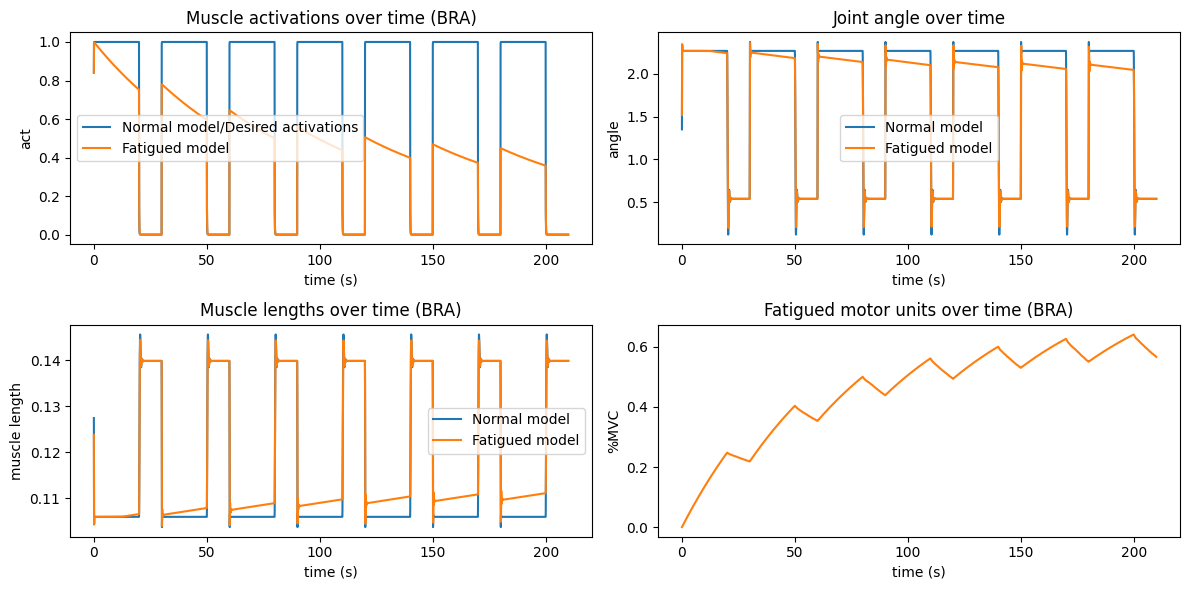

In [23]:
env.reset()
envFatigue.reset()
data_store = []
data_store_f = []
for i in range(7*3): # 7 batches of 3 episodes, with 2 episodes of maximum muscle controls for some muscles followed by a resting episode (i.e., zero muscle controls) in each batch
    a = np.zeros(env.unwrapped.model.nu,)
    if i%3!=2:
        a[3:]=1
    else:
        a[:]=0

    for _ in range(500): # 500 samples (=10s) for each episode
        next_o, r, done, *_, ifo = env.step(a) # take an action
        next_f_o, r_f, done_F, *_, ifo_f = envFatigue.step(a) # take an action

        data_store.append({"action":a.copy(),
                            "jpos":env.unwrapped.data.qpos.copy(),
                            "mlen":env.unwrapped.data.actuator_length.copy(),
                            "act":env.unwrapped.data.act.copy()})
        data_store_f.append({"action":a.copy(),
                            "jpos":envFatigue.unwrapped.data.qpos.copy(),
                            "mlen":envFatigue.unwrapped.data.actuator_length.copy(),
                            "MF":envFatigue.unwrapped.muscle_fatigue.MF.copy(),
                            "MR":envFatigue.unwrapped.muscle_fatigue.MR.copy(),
                            "MA":envFatigue.unwrapped.muscle_fatigue.MA.copy(),
                            "act":envFatigue.unwrapped.data.act.copy()})

dt = env.unwrapped.dt
mdl = env.unwrapped.model
env.close()
envFatigue.close()
muscle_names = [mdl.actuator(i).name for i in range(mdl.nu) if mdl.actuator_dyntype[i] == mujoco.mjtDyn.mjDYN_MUSCLE]
muscle_id = -1

plt.figure(figsize=(12, 6))
plt.subplot(221)
plt.plot(dt*np.arange(len(data_store)), np.array([d['act'][muscle_id] for d in data_store]), label="Normal model/Desired activations")
plt.plot(dt*np.arange(len(data_store)), np.array([d['act'][muscle_id] for d in data_store_f]), label='Fatigued model')
plt.legend()
plt.title(f'Muscle activations over time ({muscle_names[muscle_id]})')
plt.xlabel('time (s)'),plt.ylabel('act')

plt.subplot(222)
plt.plot(dt*np.arange(len(data_store)), np.array([d['jpos'] for d in data_store]), label="Normal model")
plt.plot(dt*np.arange(len(data_store)), np.array([d['jpos'] for d in data_store_f]), label="Fatigued model")
plt.legend()
plt.title('Joint angle over time')
plt.xlabel('time (s)'),plt.ylabel('angle')

plt.subplot(223)
plt.plot(dt*np.arange(len(data_store)), np.array([d['mlen'][muscle_id] for d in data_store]), label="Normal model")
plt.plot(dt*np.arange(len(data_store)), np.array([d['mlen'][muscle_id] for d in data_store_f]), label="Fatigued model")
plt.legend()
plt.title(f'Muscle lengths over time ({muscle_names[muscle_id]})')
plt.xlabel('time (s)'),plt.ylabel('muscle length')

plt.subplot(224)
plt.plot(dt*np.arange(len(data_store)), np.array([d['MF'][muscle_id] for d in data_store_f]), color="tab:orange")
plt.title(f'Fatigued motor units over time ({muscle_names[muscle_id]})')
plt.xlabel('time (s)'),plt.ylabel('%MVC')

plt.tight_layout()
plt.show()


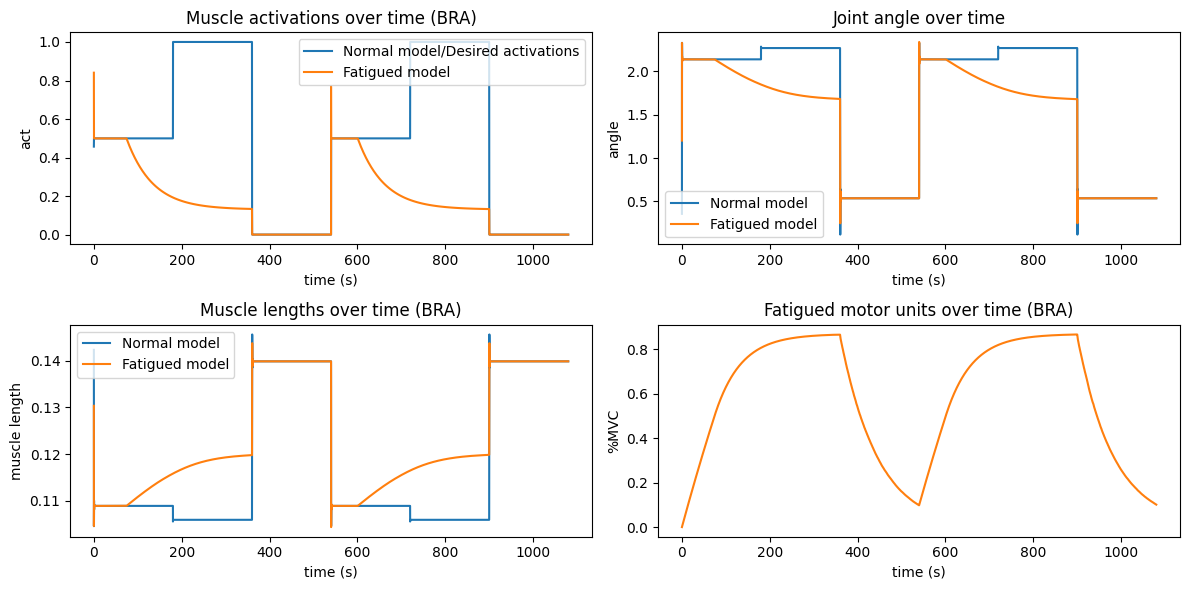

In [24]:
env.reset()
envFatigue.reset()
data_store = []
data_store_f = []
for i in range(2*3): # 2 batches of 3 episodes, with 0.5*MVC in first and 1*MVC in second episode, followed by a resting episode (i.e., zero muscle controls) in each batch
    a = np.zeros(env.unwrapped.model.nu,)
    if i%3==0:
        a[3:]=0.5
    elif i%3==1:
        a[3:]=1
    else:
        a[:]=0

    for _ in range(9000): # 9000 samples (=3 minutes) for each episode
        next_o, r, done, *_, ifo = env.step(a) # take an action
        next_f_o, r_f, done_F, *_, ifo_f = envFatigue.step(a) # take an action

        data_store.append({"action":a.copy(),
                            "jpos":env.unwrapped.data.qpos.copy(),
                            "mlen":env.unwrapped.data.actuator_length.copy(),
                            "act":env.unwrapped.data.act.copy()})
        data_store_f.append({"action":a.copy(),
                            "jpos":envFatigue.unwrapped.data.qpos.copy(),
                            "mlen":envFatigue.unwrapped.data.actuator_length.copy(),
                            "MF":envFatigue.unwrapped.muscle_fatigue.MF.copy(),
                            "MR":envFatigue.unwrapped.muscle_fatigue.MR.copy(),
                            "MA":envFatigue.unwrapped.muscle_fatigue.MA.copy(),
                            "act":envFatigue.unwrapped.data.act.copy()})

dt = env.unwrapped.dt
mdl = env.unwrapped.model
env.close()
envFatigue.close()
muscle_names = [mdl.actuator(i).name for i in range(mdl.nu) if mdl.actuator_dyntype[i] == mujoco.mjtDyn.mjDYN_MUSCLE]
muscle_id = -1

plt.figure(figsize=(12, 6))
plt.subplot(221)
plt.plot(dt*np.arange(len(data_store)), np.array([d['act'][muscle_id] for d in data_store]), label="Normal model/Desired activations")
plt.plot(dt*np.arange(len(data_store)), np.array([d['act'][muscle_id] for d in data_store_f]), label='Fatigued model')
plt.legend()
plt.title(f'Muscle activations over time ({muscle_names[muscle_id]})')
plt.xlabel('time (s)'),plt.ylabel('act')

plt.subplot(222)
plt.plot(dt*np.arange(len(data_store)), np.array([d['jpos'] for d in data_store]), label="Normal model")
plt.plot(dt*np.arange(len(data_store)), np.array([d['jpos'] for d in data_store_f]), label="Fatigued model")
plt.legend()
plt.title('Joint angle over time')
plt.xlabel('time (s)'),plt.ylabel('angle')

plt.subplot(223)
plt.plot(dt*np.arange(len(data_store)), np.array([d['mlen'][muscle_id] for d in data_store]), label="Normal model")
plt.plot(dt*np.arange(len(data_store)), np.array([d['mlen'][muscle_id] for d in data_store_f]), label="Fatigued model")
plt.legend()
plt.title(f'Muscle lengths over time ({muscle_names[muscle_id]})')
plt.xlabel('time (s)'),plt.ylabel('muscle length')

plt.subplot(224)
plt.plot(dt*np.arange(len(data_store)), np.array([d['MF'][muscle_id] for d in data_store_f]), color="tab:orange")
plt.title(f'Fatigued motor units over time ({muscle_names[muscle_id]})')
plt.xlabel('time (s)'),plt.ylabel('%MVC')

plt.tight_layout()
plt.show()


## Train Agents with Fatigue

> **⚠️ Warning:** the training below (500,000 PPO steps on CPU) may take **several minutes**. Reduce `total_timesteps` for a quick test, or skip this section and use previously trained checkpoints.

In [25]:
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback, CheckpointCallback, EvalCallback

In [26]:
env_name = "myoFatiElbowPose1D6MRandom-v0"

env = gym.make(env_name)
env.unwrapped.set_fatigue_reset_random(True)
env.reset()

# Save a checkpoint every 50000 steps
checkpoint_callback = CheckpointCallback(
  save_freq=50000,
  save_path=f"./{env_name}/iterations/",
  name_prefix="rl_model",
  save_replay_buffer=True,
  save_vecnormalize=True,
)

# PPO's success rate on this task jumps between checkpoints (a policy that reaches the
# target within the success threshold at one checkpoint can miss it at the next), so
# the last checkpoint is not necessarily the best. Evaluate deterministically every
# 10000 steps on the target used in the evaluation below (unfatigued start) and keep the
# best model in ./<env_name>/best/best_model.zip.
eval_env = gym.make(env_name)
eval_env.unwrapped.set_fatigue_reset_random(False)
eval_env.unwrapped.target_type = 'fixed'
eval_env.unwrapped.target_jnt_value = eval_env.unwrapped._target_jnt_range[:, 1]
eval_callback = EvalCallback(
  eval_env,
  best_model_save_path=f"./{env_name}/best/",
  eval_freq=10000,
  n_eval_episodes=3,
  deterministic=True,
)

# Progress bar via tqdm. (SB3's built-in `progress_bar=True` uses rich, which needs the
# ipywidgets "Output" widget and fails to render in some Jupyter front ends, e.g. VS Code.)
try:
    from tqdm.auto import tqdm
except ImportError:
    tqdm = None
    print("Install tqdm (pip install tqdm) for a training progress bar.")


class TqdmProgress(BaseCallback):
    """Update a tqdm progress bar with the number of environment steps taken."""

    def __init__(self, total_timesteps: int):
        super().__init__()
        self.total_timesteps = total_timesteps
        self.bar = None

    def _on_training_start(self) -> None:
        self.bar = tqdm(total=self.total_timesteps, desc="Training", unit="step")

    def _on_step(self) -> bool:
        self.bar.update(self.training_env.num_envs)
        return True

    def _on_training_end(self) -> None:
        self.bar.close()


TOTAL_TIMESTEPS = 500000  # 200000 is often not enough for the success rate to converge
callbacks = [checkpoint_callback, eval_callback] + ([TqdmProgress(TOTAL_TIMESTEPS)] if tqdm else [])

model = PPO("MlpPolicy", env, verbose=0, device="cpu")
model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=callbacks)

Training:   0%|          | 0/500000 [00:00<?, ?step/s]

stable_baselines3/common/evaluation.py:70: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


Eval num_timesteps=10000, episode_reward=-109.81 +/- 2.64
Episode length: 100.00 +/- 0.00
New best mean reward!
Eval num_timesteps=20000, episode_reward=-52.86 +/- 7.53
Episode length: 100.00 +/- 0.00
New best mean reward!
Eval num_timesteps=30000, episode_reward=0.88 +/- 6.39
Episode length: 100.00 +/- 0.00
New best mean reward!
Eval num_timesteps=40000, episode_reward=46.80 +/- 14.33
Episode length: 100.00 +/- 0.00
New best mean reward!
Eval num_timesteps=50000, episode_reward=392.32 +/- 14.68
Episode length: 100.00 +/- 0.00
New best mean reward!
Eval num_timesteps=60000, episode_reward=436.11 +/- 7.46
Episode length: 100.00 +/- 0.00
New best mean reward!
Eval num_timesteps=70000, episode_reward=641.96 +/- 4.86
Episode length: 100.00 +/- 0.00
New best mean reward!
Eval num_timesteps=80000, episode_reward=683.58 +/- 30.76
Episode length: 100.00 +/- 0.00
New best mean reward!
Eval num_timesteps=90000, episode_reward=690.90 +/- 33.49
Episode length: 100.00 +/- 0.00
New best mean reward!

**NOTE:** By default, random fatigue states are sampled at the beginning of each training episode. \
To start with a specific, fixed fatigue state, set `fatigue_reset_random=False` and define `fatigue_reset_vec` as the vector MF of fatigued motor units per muscle.

Best practice is to create a new  of the desired environment, i.e., calling `register_env_variant()` with
`variants={'muscle_condition': 'fatigue',
            'fatigue_reset_vec': np.array([0., 0., 0.]),
            'fatigue_reset_random': False}`.


## Simulate and Evaluate Trained Agents

In the following, we evaluate the latest policy trained for a given fatigue environment (and for comparison also the policy trained in the respective non-fatigue environment).

To this end, we simulate several episodes per policy, with fatigue accumulating across episodes, starting in the default zero fatigue state. \
Videos of the first and the last few episodes are generated, and simulation data is logged (and later visualised) for all episodes.

### Example 1: Fatigue

In [27]:
env_name = "myoFatiElbowPose1D6MRandom-v0"

GENERATE_VIDEO = True
GENERATE_VIDEO_EPS = 4  #number of episodes that are rendered BOTH at the beginning (i.e., without fatigue) and at the end (i.e., with fatigue)

STORE_DATA = True  #store collected data from evaluation run in .npy file
n_eps = 8  # student-length demo; raise to 250 to watch fatigue accumulate

###################################

env = gym.make(env_name, render_mode="rgb_array")
_ctrl_dt = float(env.unwrapped.dt)
renderer   = mujoco.Renderer(env.unwrapped.model, height=400, width=400)
scene_opt  = mujoco.MjvOption()
scene_opt.flags[int(mujoco.mjtVisFlag.mjVIS_TRANSPARENT)] = False

from pathlib import Path as _Path
# Best model of the training run (EvalCallback) if present, else the checkpoint with the
# highest step count (sorted numerically: as text, "..._90000_steps" would come after "..._200000_steps").
_best, _cands = [], []
for _base in (_Path.cwd(), _Path.cwd() / "tutorials"):
    _best.extend((_base / env_name / "best").glob("best_model.zip"))
    _cands.extend(sorted((_base / env_name).glob("iterations/rl_model_*_steps.zip"),
                         key=lambda _p: int(_p.stem.split("_")[2])))
model_path = str(_best[-1]) if _best else (str(_cands[-1]) if _cands else f"{env_name}/best/best_model.zip")
from stable_baselines3 import PPO
if os.path.exists(model_path):
    model = PPO.load(model_path)
    print("Loaded", model_path)
    def _act(o):
        return model.predict(o, deterministic=True)[0]
else:
    print("PPO checkpoint not found; using random actions so the fatigue demo still runs.")
    def _act(o):
        return env.action_space.sample()
if True:

    env.unwrapped.set_fatigue_reset_random(False)
    env.unwrapped.target_type = 'fixed'
    env.unwrapped.target_jnt_value = env.unwrapped._target_jnt_range[:, 1]
    env.reset(options={"fatigue_reset": True})  #ensure that fatigue is reset before the simulation starts

    if int(env.unwrapped.model.ncam) > 0:
        env.unwrapped.model.cam_poscom0[0] = np.array([-1.3955, -0.3287, 0.6579])

    data_store = []
    if GENERATE_VIDEO:
        frames = []

    start_time = time.time()
    for ep in range(n_eps):
        print("Ep {} of {}".format(ep, n_eps))

        for _cstep in range(env.spec.max_episode_steps):
            if GENERATE_VIDEO and (ep in range(GENERATE_VIDEO_EPS) or ep in range(n_eps-GENERATE_VIDEO_EPS, n_eps)):
                renderer.update_scene(env.unwrapped.data, camera=-1, scene_option=scene_opt)
                frame = renderer.render()

                # Add text overlay
                _current_time = (ep*env.spec.max_episode_steps + _cstep)*_ctrl_dt
                frame = np.array(add_text_to_frame(frame,
                        f"t={str(int(_current_time//60)).zfill(2)}:{str(int(_current_time%60)).zfill(2)}min",
                        pos=(285, 3), color=(0, 0, 0), fontsize=18))

                frames.append(frame)
            o = env.unwrapped.get_obs()
            a = _act(o)
            next_o, r, done, _, ifo = env.step(a) # take an action based on the current observation

            data_store.append({"action":a.copy(),
                                "jpos":env.unwrapped.data.qpos.copy(),
                                "mlen":env.unwrapped.data.actuator_length.copy(),
                                "act":env.unwrapped.data.act.copy(),
                                "reward":r,
                                "solved":ifo['rwd_dict']['solved'].item(),
                                "pose_err":env.unwrapped.get_obs_dict(env.unwrapped._accessor)["pose_err"],
                                "MA":env.unwrapped.muscle_fatigue.MA.copy(),
                                "MR":env.unwrapped.muscle_fatigue.MR.copy(),
                                "MF":env.unwrapped.muscle_fatigue.MF.copy(),
                                "ctrl":env.unwrapped.data.ctrl.copy()})
    env.close()

    ## OPTIONALLY: Stored simulated data
    if STORE_DATA:
        os.makedirs(f"{env_name}/logs", exist_ok=True)
        np.save(f"{env_name}/logs/fatitest.npy", data_store)

    ## OPTIONALLY: Render video
    if GENERATE_VIDEO:
        os.makedirs(f'{env_name}/videos', exist_ok=True)
        # make a local copy
        write_video(f'{env_name}/videos/fatitest.mp4', np.asarray(frames), inputdict={'-r': str(int(1/_ctrl_dt))}, outputdict={"-pix_fmt": "yuv420p"})

    end_time = time.time()
    print(f"DURATION: {end_time - start_time:.2f}s")

    if GENERATE_VIDEO:
        display(show_video(f'{env_name}/videos/fatitest.mp4'))


Loaded myoFatiElbowPose1D6MRandom-v0/best/best_model.zip
Ep 0 of 8
Ep 1 of 8
Ep 2 of 8
Ep 3 of 8
Ep 4 of 8
Ep 5 of 8
Ep 6 of 8
Ep 7 of 8
DURATION: 6.40s


Multiple -pix_fmt options specified for stream 0, only the last option '-pix_fmt yuv420p' will be used.


Muscle Fatigue Equilibrium: [2.15131517e-04 1.86620748e-04 5.75623256e-04 5.06379932e-02
 4.63244980e-02 2.18685424e-01]


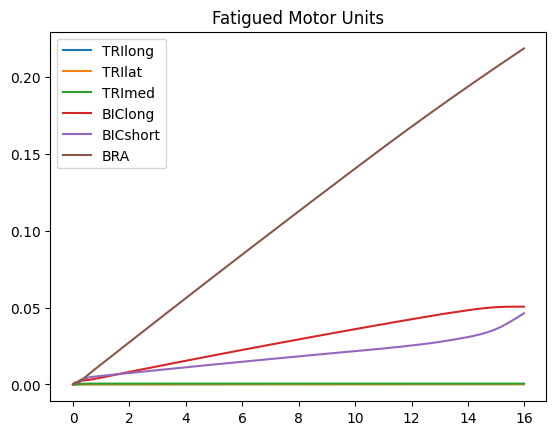

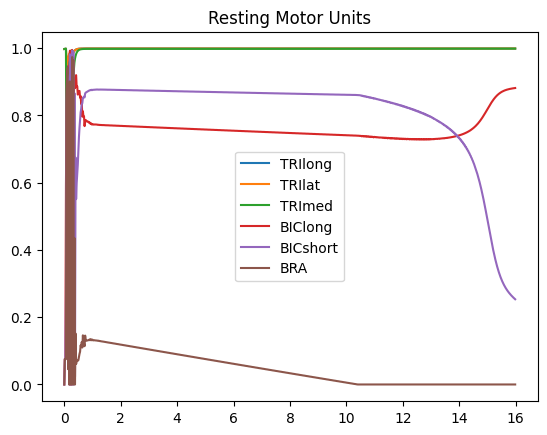

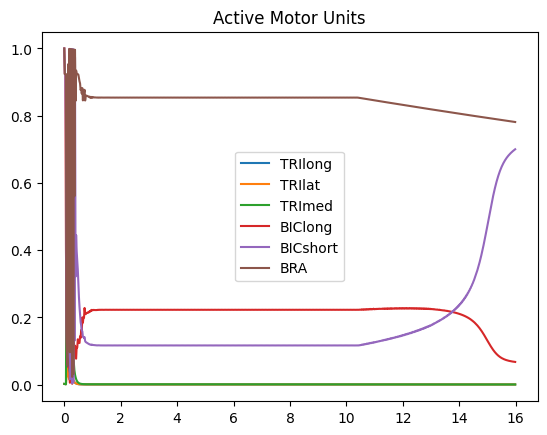

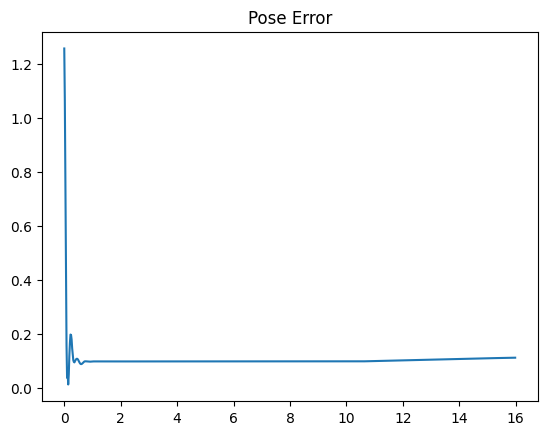

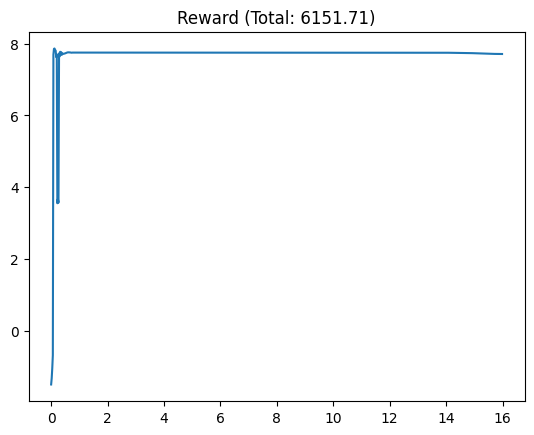

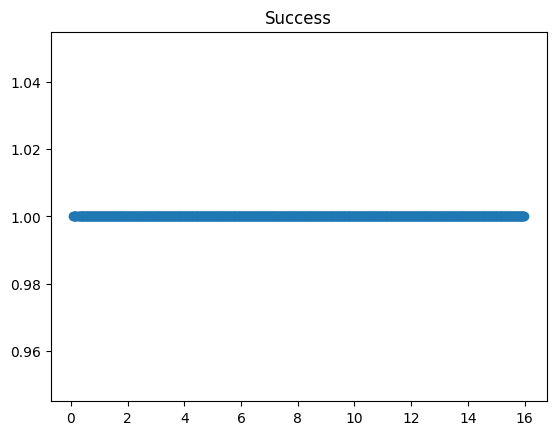

In [28]:
env_name = "myoFatiElbowPose1D6MRandom-v0"

####################

data_path = f"{env_name}/logs/fatitest.npy"
if not os.path.exists(data_path):
    print("No fatitest.npy; run previous cell with a trained model first.")
else:
    env_test = gym.make(env_name, normalize_act=False)
    mdl = env_test.unwrapped.model
    muscle_names = [mdl.actuator(i).name for i in range(mdl.nu) if mdl.actuator_dyntype[i] == mujoco.mjtDyn.mjDYN_MUSCLE]
    _env_dt = env_test.unwrapped.dt  #0.02

    data_store = np.load(data_path, allow_pickle=True)

    plt.figure()
    for _muscleid in range(len(data_store[0]['MF'])):
        plt.plot(_env_dt*np.arange(len(data_store)), np.array([d['MF'][_muscleid] for d in data_store]), label=muscle_names[_muscleid])
    plt.legend()
    plt.title('Fatigued Motor Units')

    plt.figure()
    for _muscleid in range(len(data_store[0]['MR'])):
        plt.plot(_env_dt*np.arange(len(data_store)), np.array([d['MR'][_muscleid] for d in data_store]), label=muscle_names[_muscleid])
    plt.legend()
    plt.title('Resting Motor Units')

    plt.figure()
    for _muscleid in range(len(data_store[0]['MA'])):
        plt.plot(_env_dt*np.arange(len(data_store)), np.array([d['MA'][_muscleid] for d in data_store]), label=muscle_names[_muscleid])
    plt.legend()
    plt.title('Active Motor Units')

    plt.figure()
    plt.plot(_env_dt*np.arange(len(data_store)), np.array([np.linalg.norm(d['pose_err']) for d in data_store])), plt.title('Pose Error')

    plt.figure()
    plt.plot(_env_dt*np.arange(len(data_store)), np.array([d['reward'] for d in data_store])), plt.title(f"Reward (Total: {np.array([d['reward'] for d in data_store]).sum():.2f})")

    if "solved" in data_store[0]:
        plt.figure()
        plt.scatter(_env_dt*np.arange(len(data_store))[np.array([d['solved'] for d in data_store])], np.array([d['solved'] for d in data_store])[np.array([d['solved'] for d in data_store])]), plt.title(f"Success")

    print(f"Muscle Fatigue Equilibrium: {data_store[-1]['MF']}")

Comparison: Policy trained without fatigue

### Example 2: Fatigue + Resting Period

In this variant, the same target needs to be reached for 5 minutes, followed by a resting period of 2:30 minutes, and another 2:30 minutes of the same task.

In [29]:
env_name = "myoFatiElbowPose1D6MRandom-v0"

GENERATE_VIDEO = True
GENERATE_VIDEO_EPS = 2  # first/last episodes rendered; raise for a longer video

STORE_DATA = True  #store collected data from evaluation run in .npy file
n_eps = 8  # student-length demo; raise to 300 for a full fatigue sweep

###################################

env = gym.make(env_name, render_mode="rgb_array")
_ctrl_dt = float(env.unwrapped.dt)
renderer   = mujoco.Renderer(env.unwrapped.model, height=400, width=400)
scene_opt  = mujoco.MjvOption()
scene_opt.flags[int(mujoco.mjtVisFlag.mjVIS_TRANSPARENT)] = False

from pathlib import Path as _Path
# Best model of the training run (EvalCallback) if present, else the checkpoint with the
# highest step count (sorted numerically: as text, "..._90000_steps" would come after "..._200000_steps").
_best, _cands = [], []
for _base in (_Path.cwd(), _Path.cwd() / "tutorials"):
    _best.extend((_base / env_name / "best").glob("best_model.zip"))
    _cands.extend(sorted((_base / env_name).glob("iterations/rl_model_*_steps.zip"),
                         key=lambda _p: int(_p.stem.split("_")[2])))
model_path = str(_best[-1]) if _best else (str(_cands[-1]) if _cands else f"{env_name}/best/best_model.zip")
from stable_baselines3 import PPO
if os.path.exists(model_path):
    model = PPO.load(model_path)
    print("Loaded", model_path)
    def _act(o):
        return model.predict(o, deterministic=True)[0]
else:
    print("PPO checkpoint not found; using random actions so the fatigue demo still runs.")
    def _act(o):
        return env.action_space.sample()
if True:

    env.unwrapped.set_fatigue_reset_random(False)
    env.unwrapped.target_type = 'fixed'
    env.unwrapped.target_jnt_value = env.unwrapped._target_jnt_range[:, 1]
    env.reset(options={"fatigue_reset": True})  #ensure that fatigue is reset before the simulation starts

    if int(env.unwrapped.model.ncam) > 0:
        env.unwrapped.model.cam_poscom0[0] = np.array([-1.3955, -0.3287, 0.6579])

    data_store = []
    if GENERATE_VIDEO:
        frames = []

    start_time = time.time()
    for ep in range(n_eps):
        print("Ep {} of {}".format(ep, n_eps))

        for _cstep in range(env.spec.max_episode_steps):
            if GENERATE_VIDEO and (ep in range(GENERATE_VIDEO_EPS) or ep in range(n_eps-GENERATE_VIDEO_EPS, n_eps)):
                renderer.update_scene(env.unwrapped.data, camera=-1, scene_option=scene_opt)
                frame = renderer.render()

                # Add text overlay
                _current_time = (ep*env.spec.max_episode_steps + _cstep)*_ctrl_dt
                frame = np.array(add_text_to_frame(frame,
                        f"t={str(int(_current_time//60)).zfill(2)}:{str(int(_current_time%60)).zfill(2)}min",
                        pos=(285, 3), color=(0, 0, 0), fontsize=18))

                if ep >= n_eps*0.5 and ep < n_eps*0.75:
                    frame = np.array(add_text_to_frame(frame,
                        f"Resting Phase",
                        pos=(240, 380), color=(84, 184, 81), fontsize=18))

                frames.append(frame)
            o = env.unwrapped.get_obs()
            a = _act(o)

            if ep >= n_eps*0.5 and ep < n_eps*0.75:
                a[:] = -100000  #resting period (corresponds to zero muscle activations)
                env.unwrapped.model.site_rgba[env.unwrapped.target_sids[0]][-1] = 0  #hide target during resting period
                env.unwrapped.model.tendon_rgba[-1][-1] = 0  #hide error line during resting period
            else:
                env.unwrapped.model.site_rgba[env.unwrapped.target_sids[0]][-1] = 0.2  #visualise target during task
                env.unwrapped.model.tendon_rgba[-1][-1] = 0.2  #visualise error line during task

            next_o, r, done, _, ifo = env.step(a) # take an action based on the current observation

            data_store.append({"action":a.copy(),
                                "jpos":env.unwrapped.data.qpos.copy(),
                                "mlen":env.unwrapped.data.actuator_length.copy(),
                                "act":env.unwrapped.data.act.copy(),
                                "reward":r,
                                "solved":ifo['rwd_dict']['solved'].item(),
                                "pose_err":env.unwrapped.get_obs_dict(env.unwrapped._accessor)["pose_err"],
                                "MA":env.unwrapped.muscle_fatigue.MA.copy(),
                                "MR":env.unwrapped.muscle_fatigue.MR.copy(),
                                "MF":env.unwrapped.muscle_fatigue.MF.copy(),
                                "ctrl":env.unwrapped.data.ctrl.copy()})
    env.close()

    ## OPTIONALLY: Stored simulated data
    if STORE_DATA:
        os.makedirs(f"{env_name}/logs", exist_ok=True)
        np.save(f"{env_name}/logs/fatitest_recovery.npy", data_store)

    ## OPTIONALLY: Render video
    if GENERATE_VIDEO:
        os.makedirs(f'{env_name}/videos', exist_ok=True)
        # make a local copy
        write_video(f'{env_name}/videos/fatitest_recovery.mp4', np.asarray(frames), inputdict={'-r': str(int(1/_ctrl_dt))}, outputdict={"-pix_fmt": "yuv420p"})

    end_time = time.time()
    print(f"DURATION: {end_time - start_time:.2f}s")

    if GENERATE_VIDEO:
        display(show_video(f'{env_name}/videos/fatitest_recovery.mp4'))


Loaded myoFatiElbowPose1D6MRandom-v0/best/best_model.zip
Ep 0 of 8
Ep 1 of 8
Ep 2 of 8
Ep 3 of 8
Ep 4 of 8
Ep 5 of 8
Ep 6 of 8
Ep 7 of 8
DURATION: 5.08s


Multiple -pix_fmt options specified for stream 0, only the last option '-pix_fmt yuv420p' will be used.


Muscle Fatigue Equilibrium: [0.00058191 0.00048763 0.00093876 0.04153807 0.02727792 0.159935  ]


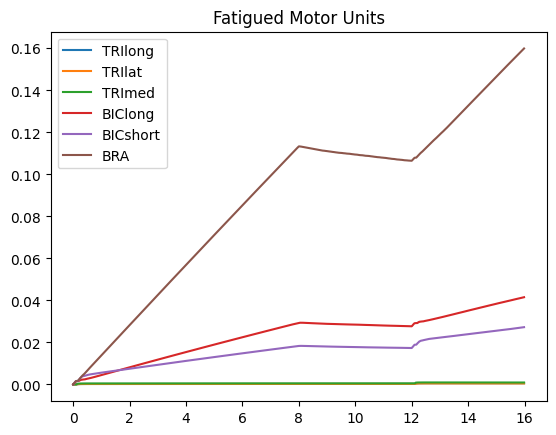

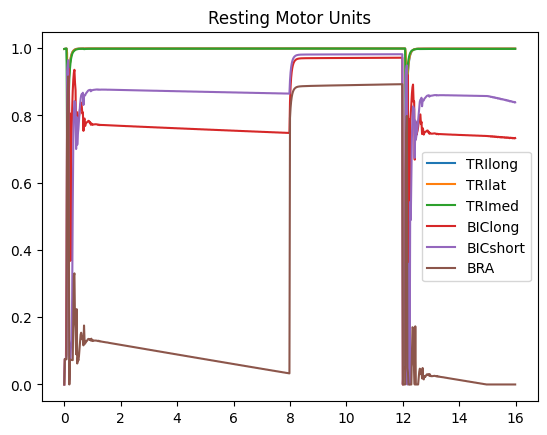

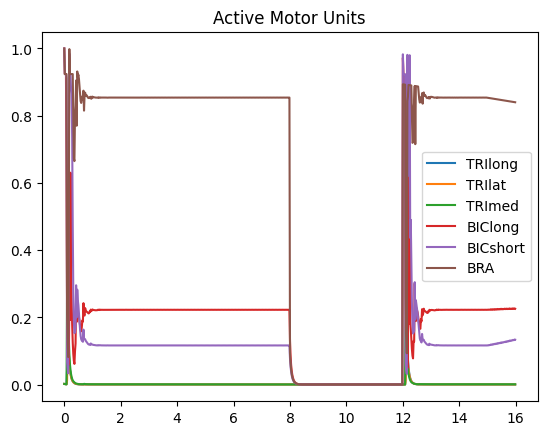

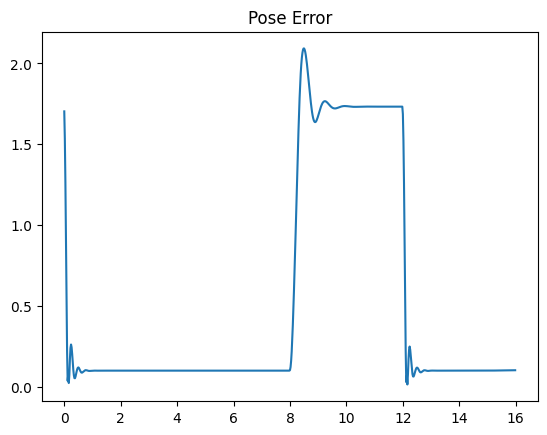

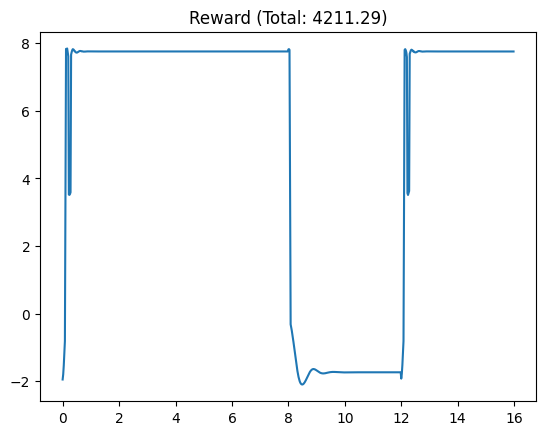

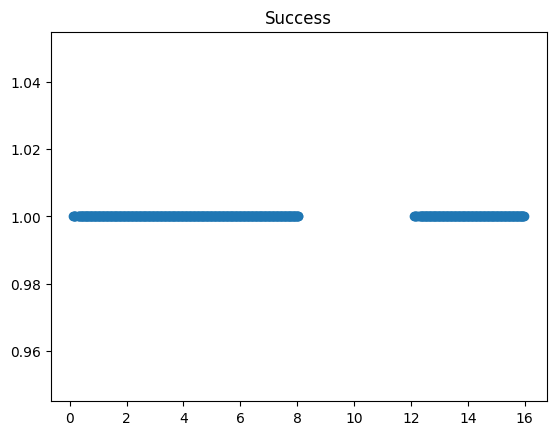

In [30]:
env_name = "myoFatiElbowPose1D6MRandom-v0"

####################

data_path = f"{env_name}/logs/fatitest_recovery.npy"
if not os.path.exists(data_path):
    print("No fatitest_recovery.npy; run previous cell (Example 2) with a trained model first.")
else:
    env_test = gym.make(env_name, normalize_act=False)
    mdl = env_test.unwrapped.model
    muscle_names = [mdl.actuator(i).name for i in range(mdl.nu) if mdl.actuator_dyntype[i] == mujoco.mjtDyn.mjDYN_MUSCLE]
    _env_dt = env_test.unwrapped.dt  #0.02

    data_store = np.load(data_path, allow_pickle=True)

    plt.figure()
    for _muscleid in range(len(data_store[0]['MF'])):
        plt.plot(_env_dt*np.arange(len(data_store)), np.array([d['MF'][_muscleid] for d in data_store]), label=muscle_names[_muscleid])
    plt.legend()
    plt.title('Fatigued Motor Units')

    plt.figure()
    for _muscleid in range(len(data_store[0]['MR'])):
        plt.plot(_env_dt*np.arange(len(data_store)), np.array([d['MR'][_muscleid] for d in data_store]), label=muscle_names[_muscleid])
    plt.legend()
    plt.title('Resting Motor Units')

    plt.figure()
    for _muscleid in range(len(data_store[0]['MA'])):
        plt.plot(_env_dt*np.arange(len(data_store)), np.array([d['MA'][_muscleid] for d in data_store]), label=muscle_names[_muscleid])
    plt.legend()
    plt.title('Active Motor Units')

    plt.figure()
    plt.plot(_env_dt*np.arange(len(data_store)), np.array([np.linalg.norm(d['pose_err']) for d in data_store])), plt.title('Pose Error')

    plt.figure()
    plt.plot(_env_dt*np.arange(len(data_store)), np.array([d['reward'] for d in data_store])), plt.title(f"Reward (Total: {np.array([d['reward'] for d in data_store]).sum():.2f})")

    if "solved" in data_store[0]:
        plt.figure()
        plt.scatter(_env_dt*np.arange(len(data_store))[np.array([d['solved'] for d in data_store])], np.array([d['solved'] for d in data_store])[np.array([d['solved'] for d in data_store])]), plt.title(f"Success")

    print(f"Muscle Fatigue Equilibrium: {data_store[-1]['MF']}")